In [12]:
import torch
from torch import nn, optim

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.image as img
from tqdm.notebook import tqdm
import numpy as np

dirstar = 'D:/jwst_data/prod/mastDownload/JWST/**/'

In [164]:
coronagraphs = {}
wcs = {}

fnames = glob(dirstar + '*_miri_f*_i2d.fits')
# fnames = glob(dirstar + '*_cal.fits')
for fname in tqdm(fnames):
    with fits.open(fname)  as hdul:
        target = hdul[0].header['TARGNAME']
        filt = hdul[0].header['APERNAME'].split('_')[1].lower()
        if target == '* bet Pic':
            target = 'beta Pic'
        print(target, filt)
        if target not in coronagraphs:
            coronagraphs[target] = {}
            wcs[target] = WCS(hdul[1].header)
        if filt not in coronagraphs[target]:
            if len(hdul[1].data.shape) > 2:
                data, mask = reproject_interp((np.nanmedian(hdul[1].data,axis=0),hdul[1].header),wcs[target],shape_out=(250,250))
            else:
                data, mask = reproject_interp((hdul[1].data,hdul[1].header),wcs[target],shape_out=(280,280))
            coronagraphs[target][filt] = data

  0%|          | 0/55 [00:00<?, ?it/s]

HD 92209 mask1140
* alf PsA mask1550
* alf Lyr mask1550
HR8799 mask1065
HR8799 mask1140
HR8799 mask1550
51 Eri mask1065
51 Eri mask1140
51 Eri mask1550
kappa And mask1065
kappa And mask1140
kappa And mask1550
beta Pic mask1065
beta Pic mask1140
HR 2562 mask1065
HR 2562 mask1140
HR 2562 mask1550
GJ 504 mask1065
HD 95086 mask1065
HD 106906 mask1140
GJ 504 mask1140
HD 95086 mask1140
TW-Hya.CORO mask1550
HD 116434 mask1140
HD 116434 mask1550
HD 141569 mask1065
HD 141569 mask1140
HD 141569 mask1550
beta Pic mask1550
GJ-758 mask1065
GJ-758 mask1140
GJ-758 mask1550
dr3-5877725249280411392 mask1550
DR3-5877725111863605376 mask1550
HD107146 mask1140
HD92945 mask1140
HD206893 mask1140
* eps Ind mask1065
* eps Ind mask1550
HD 202628 mask1140
BD+40 45 mask1140
WRAY 15-1880 mask1140
LkCa 15 mask1140
WRAY 15-1443 mask1140
V* SY Cha mask1140
TWA7 mask1140
HD 181327 mask1140
HD 169142 mask1065
GJ 179 mask1550
Gaia DR3 5877725249280411392 mask1550
Gaia DR3 5877725249280411392 mask1550
HIP 108706 mask10

C:\Users\natha\AppData\Local\Temp\ipykernel_5960\380857766.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


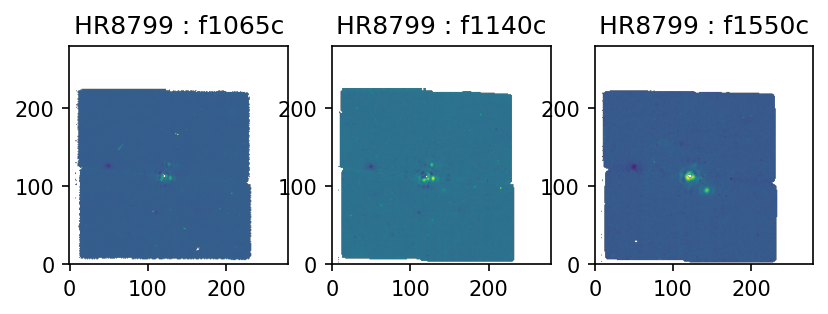

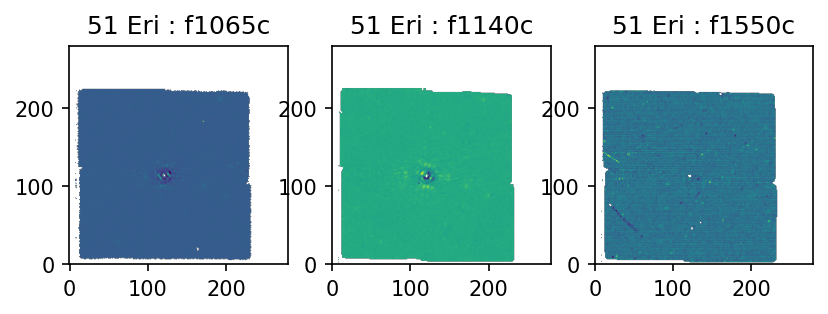

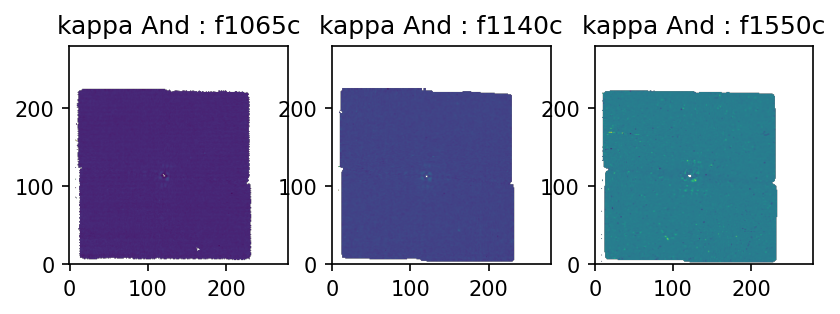

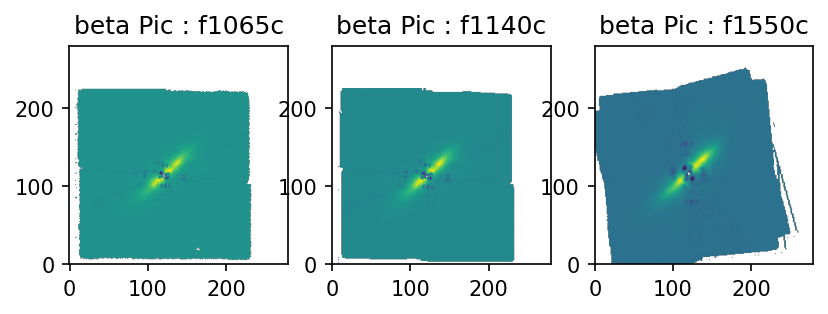

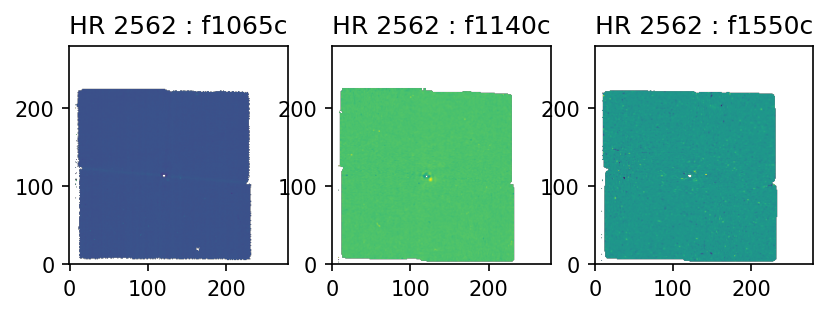

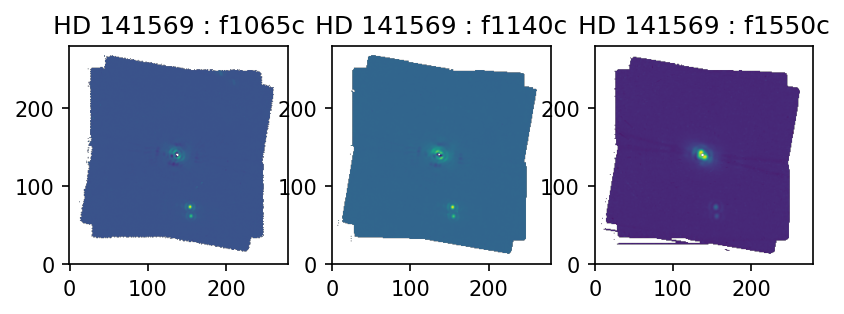

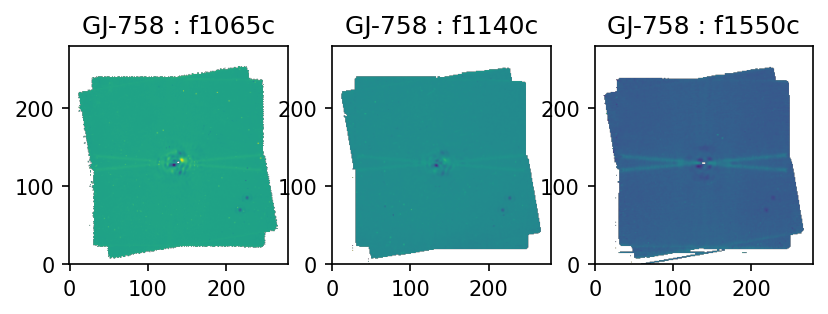

In [165]:
keys = set(coronagraphs.keys())
for target in keys:
    if len(coronagraphs[target]) < 3:
        coronagraphs.pop(target)
# bad data
# observations.pop((np.float64(236.69),np.float64(-6.12)))

for target in coronagraphs:
    fig, axs = plt.subplots(1,3)
    if 'mask1065' in coronagraphs[target]:
        axs[0].imshow(coronagraphs[target]['mask1065'], origin='lower')
        axs[0].set_title(f'{target} : f1065c')
    if 'mask1140' in coronagraphs[target]:
        axs[1].imshow(coronagraphs[target]['mask1140'], origin='lower')
        axs[1].set_title(f'{target} : f1140c')
    if 'mask1550' in coronagraphs[target]:
        axs[2].imshow(coronagraphs[target]['mask1550'], origin='lower')
        axs[2].set_title(f'{target} : f1550c')
    fig.set_dpi(150)
    fig.show()

In [143]:
ifus = {}
fnames = glob(dirstar + '*_miri_*_x1d.fits')
for fname in tqdm(fnames):
    with fits.open(fname)  as hdul:
        target = hdul[0].header['TARGNAME']
        if target not in ifus:
            ifus[target] = {}
        data = np.zeros((len(hdul[1].data),len(hdul[1].data[0])))
        for row in range(len(hdul[1].data)):
            data[row,:] = hdul[1].data[row]
        ifus[target][fname.split('_miri_')[-1].split('_')[0]] = data

  0%|          | 0/12 [00:00<?, ?it/s]

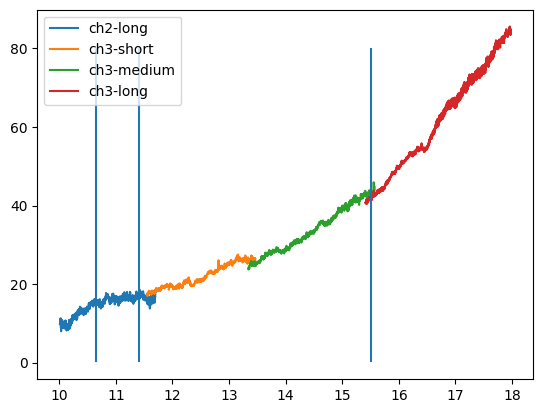

In [179]:
for filt in ['ch2-long','ch3-short','ch3-medium','ch3-long']:
    plt.plot(ifus['* bet Pic'][filt][:,0],ifus['* bet Pic'][filt][:,6],label=filt)
plt.legend()
plt.vlines([10.65,11.4,15.5],0.01, 80)
plt.show()

star_1550 = ifus['* bet Pic']['ch3-medium'][np.argmin(np.abs(ifus['* bet Pic']['ch3-medium'][:,0] - 15.5)),6]
data_1550 = np.divide(np.abs(coronagraphs['beta Pic']['mask1550']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1550'].ravel())))*star_1550
star_1140 = ifus['* bet Pic']['ch2-long'][np.argmin(np.abs(ifus['* bet Pic']['ch2-long'][:,0] - 11.4)),6]
data_1140 = np.divide(np.abs(coronagraphs['beta Pic']['mask1140']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1140'].ravel())))*star_1140
star_1065 = ifus['* bet Pic']['ch2-long'][np.argmin(np.abs(ifus['* bet Pic']['ch2-long'][:,0] - 10.65)),6]
data_1065 = np.divide(np.abs(coronagraphs['beta Pic']['mask1065']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1065'].ravel())))*star_1065

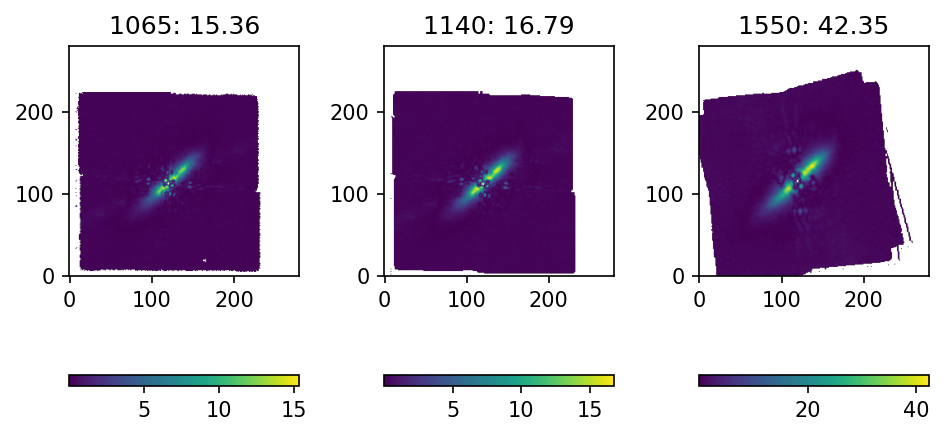

In [180]:
fig, axs = plt.subplots(1,3)
caxs = [0,0,0]

caxs[0] = axs[0].imshow(data_1065,origin='lower')
axs[0].set_title(f'1065: {star_1065:.2f}')

caxs[1] = axs[1].imshow(data_1140,origin='lower')
axs[1].set_title(f'1140: {star_1140:.2f}')

caxs[2] = axs[2].imshow(data_1550,origin='lower')
axs[2].set_title(f'1550: {star_1550:.2f}')

for j in range(3):
    plt.colorbar(caxs[j],ax=axs[j],fraction=0.05,location='bottom')

fig.set_dpi(150)
plt.tight_layout()
plt.show()

In [156]:
with fits.open(fnames[0])  as hdul:
    print(hdul[0].header['FILTER'])

FND


In [157]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2025-12-17T14:40:39.713' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01413007001_02101_00002_mirimage_cal.fits' / Name of the file      
SDP_VER = '2025_4a '           / Data Processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-072'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '008.007.000.000'    / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC31   '        